# Basics of Combinatorics

# Fundamental Counting Principles

## Sum Rule

Suppose that a task can be performed in $n_1$ ways or in $n_2$ ways, and that the two possibilities are mutually exclusive. Then the total number of possible outcomes equals $n_1+n_2$.

### Example

A class consists of 15 boys and 12 girls. If we wish to choose a class representative, then the number of possible choices is

$$15+12=27.$$

## Product Rule

Suppose that a procedure consists of $k$ consecutive steps. If Step $i$ can be performed in $n_i$ ways for every $i=1,\ldots,k$, then the total number of possible outcomes equals

$$n_1n_2\cdots n_k.$$

### Example

A password consists of three letters followed by two digits. Since each letter can be chosen in 26 ways and each digit in 10 ways, the total number of possible passwords equals

$$26^3\cdot10^2$$

## Pigeonhole Principle

If $n+1$ objects are placed into $n$ boxes, then at least one box must contain at least two objects.

### Example

Among 13 people there are always at least two born in the same month. Indeed, the objects are the people and the boxes are the months of the year. Since $13>12$, the conclusion follows immediately.

## Counting Formulas

|                     | With Repetition | Without Repetition |
|---------------------|----------------|-------------------|
| **Combinations**    | $\displaystyle \binom{n+k-1}{k}$ | $\displaystyle \binom{n}{k}$ |
| **Arrangements**    | $\displaystyle n^k$ | $\displaystyle \frac{n!}{(n-k)!}$ |

## Binomial Theorem

For every $n\in\mathbb Z_+$,

$$
(x+y)^n
=
\sum_{k=0}^{n}
\binom{n}{k}
x^k y^{\,n-k}.
$$

# Fundamental Binomial Identities

### (1) Symmetry Identity

$\binom{n}{k}=\binom{n}{n-k}$.

### (2) Pascal Identity

$\binom{n}{k}=\binom{n-1}{k}+\binom{n-1}{k-1}$.

### (3) Combinations with Repetition

$\binom{n+k-1}{k}$.

### (4) Sum of Binomial Coefficients

$\sum_{k=0}^{n}\binom{n}{k}=2^n.$

### (5) Sum of Squares

$\sum_{k=0}^{n}\binom{n}{k}^2=\binom{2n}{n}.$

### (6) Hockey-Stick Identity

$$
\binom{n+m}{n}
=
\sum_{i=0}^{m}\binom{n+i-1}{n-1}.
$$

## Useful Consequences

From the Hockey-Stick Identity we obtain

$$
\sum_{i=1}^{n}i=\frac{n(n+1)}{2}
$$

and

$$
\sum_{i=1}^{n}i^2=\frac{n(n+1)(2n+1)}{6}.
$$

# Inclusion–Exclusion Principle

Suppose that $a_1,\ldots,a_N$ are objects and $d_1,\ldots,d_n$ are properties.

Let $N(d_i)$ denote the number of objects satisfying property $d_i$, and let $N(d_{i_1},\ldots,d_{i_k})$ denote the number of objects satisfying all properties $d_{i_1},\ldots,d_{i_k}$ simultaneously.

Then the number of objects satisfying none of the properties is given by

$$
N-\sum_iN(d_i)+\sum_{i<j}N(d_i,d_j)-\sum_{i<j<k}N(d_i,d_j,d_k)+\cdots+(-1)^nN(d_1,\ldots,d_n).
$$

# Why Combinatorics Matters in Probability

In many elementary probability problems, all outcomes are assumed to be equally likely. In that case, the probability of an event $A$ is

$$
\mathbb P(A)=\frac{|A|}{|\Omega|}.
$$

Here $\Omega$ is the sample space, $|\Omega|$ is the total number of possible outcomes, and $|A|$ is the number of favorable outcomes.

Therefore, probability often begins with counting.

For example, if we toss a fair coin 10 times, then there are $2^{10}$ possible outcomes. The probability of getting exactly 4 heads is

$$
\mathbb P(\text{exactly 4 heads})
=
\frac{\binom{10}{4}}{2^{10}}.
$$

Combinatorics tells us how many outcomes are possible. Probability tells us how likely they are.

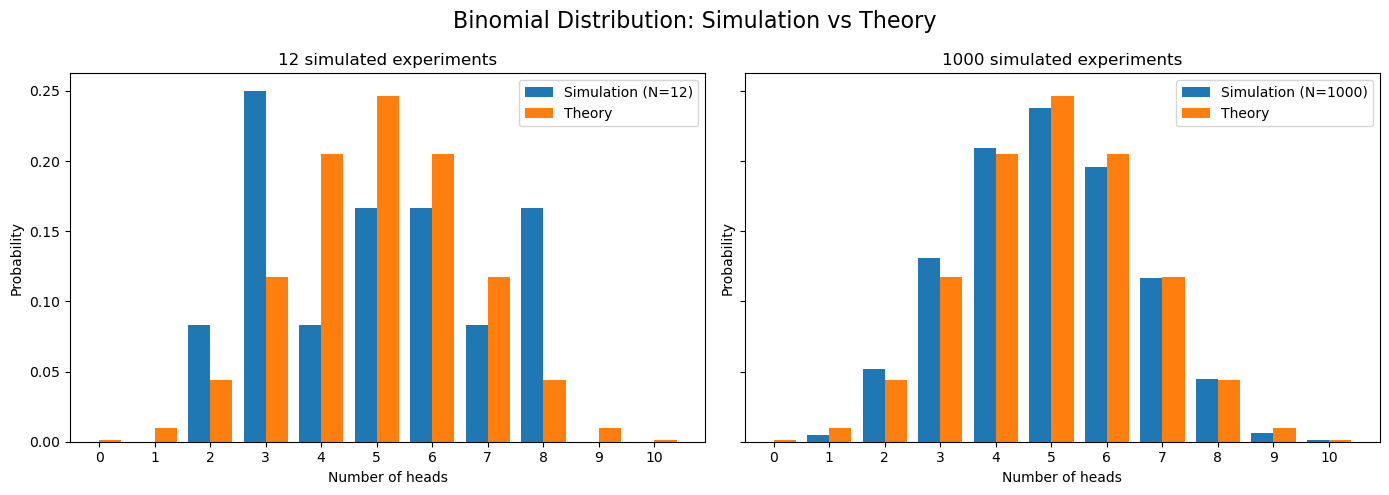

In [22]:
#Coin Toss Simulation

import numpy as np
import matplotlib.pyplot as plt
from math import comb

np.random.seed(42)

n = 10
p = 0.5

# Two different sample sizes
sample_sizes = [12, 1000]

# Theoretical probabilities
k_values = np.arange(n + 1)
theoretical_probs = np.array([
    comb(n, k) * p**k * (1 - p)**(n - k)
    for k in k_values
])

# Create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, N in zip(axes, sample_sizes):

    # Simulate N experiments
    samples = np.random.binomial(n=n, p=p, size=N)

    # Empirical probabilities
    values, counts = np.unique(samples, return_counts=True)
    empirical_probs = counts / N

    ax.bar(values - 0.2,
           empirical_probs,
           width=0.4,
           label=f"Simulation (N={N})")

    ax.bar(k_values + 0.2,
           theoretical_probs,
           width=0.4,
           label="Theory")

    ax.set_xlabel("Number of heads")
    ax.set_ylabel("Probability")
    ax.set_title(f"{N} simulated experiments")
    ax.set_xticks(k_values)
    ax.legend()

plt.suptitle("Binomial Distribution: Simulation vs Theory", fontsize=16)
plt.tight_layout()
plt.show()

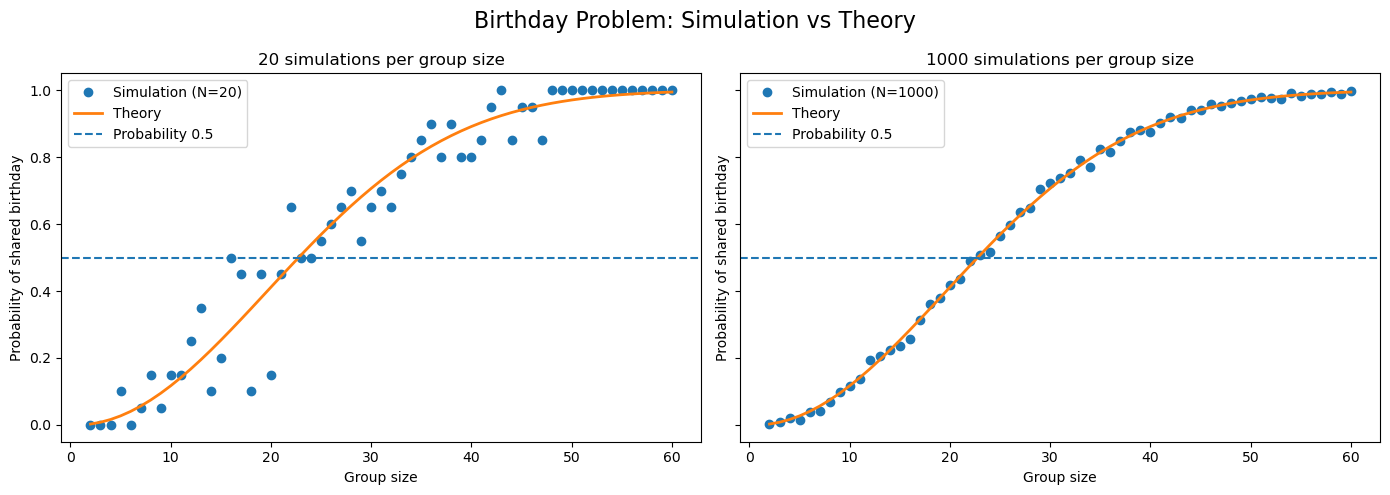

In [28]:
#  Birthday Problem Simulation
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def birthday_simulation(group_size, N):
    success = 0

    for _ in range(N):
        birthdays = np.random.randint(1, 366, size=group_size)

        if len(set(birthdays)) < group_size:
            success += 1

    return success / N


group_sizes = np.arange(2, 61)

# Theoretical probabilities
theoretical_probs = []

for n in group_sizes:
    prob_all_different = 1.0

    for k in range(n):
        prob_all_different *= (365 - k) / 365

    theoretical_probs.append(1 - prob_all_different)

theoretical_probs = np.array(theoretical_probs)

# Two different simulation sizes
sample_sizes = [20, 1000]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, N in zip(axes, sample_sizes):

    empirical_probs = np.array([
        birthday_simulation(n, N)
        for n in group_sizes
    ])

    ax.plot(group_sizes,
            empirical_probs,
            "o",
            label=f"Simulation (N={N})")

    ax.plot(group_sizes,
            theoretical_probs,
            linewidth=2,
            label="Theory")

    ax.axhline(0.5,
               linestyle="--",
               label="Probability 0.5")

    ax.set_xlabel("Group size")
    ax.set_ylabel("Probability of shared birthday")
    ax.set_title(f"{N} simulations per group size")
    ax.legend()

plt.suptitle("Birthday Problem: Simulation vs Theory", fontsize=16)

plt.tight_layout()
plt.show()